Duzhin Fedor
---

These are sort of "model answers", but it doesn't mean that these answers are the only correct ones. Besides, when grading, Fedor will pay more attention to how you justify your answer than to whether it is the same as his.

In [28]:
#@title
# This is to download pre-trained word vectors:

!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip
# !ls
# You can comment it out later

--2025-01-25 02:57:18--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-01-25 02:57:18--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-01-25 02:57:18--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.1’

gl

# Notebook 5 - Pretrained GloVe

This is a graded group assignment. After you are done, please share the link to your assignment with Fedor for grading.

In [29]:
#@title
# Libraries:
import pandas as pd
import numpy as np

import re                                  # library for regular expression operations
import string                              # for string operations
from nltk.tokenize import TweetTokenizer

# Part 1

Here we download pretrained GloVe and explore word vectors. Some useful functions will be provided for you.

In [30]:
# Word vectors:

path_to_glove_file = "glove.6B.100d.txt"

embeddings_index = {}
with open(path_to_glove_file) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

print("Found %s word vectors." % len(embeddings_index))

Found 400000 word vectors.


We have created a Python dictionary with words as keys and word vectors as values.

In [31]:
print("Type of the variable with word embeddings is", type(embeddings_index), "\n")
print("Here are the first 10 keys")
print(list(embeddings_index.keys())[:10], "\n")
print("First 5 entries of the vector v('engineer'):")
print(embeddings_index.get('engineer', 0)[:5])

Type of the variable with word embeddings is <class 'dict'> 

Here are the first 10 keys
['the', ',', '.', 'of', 'to', 'and', 'in', 'a', '"', "'s"] 

First 5 entries of the vector v('engineer'):
[-0.22299 -0.50327 -0.1059  -0.12002  0.5725 ]


Note that we can access dictionary elements via either
`dict[key]` or `dict.get(key, alt)`. The first method will produce an error if the key is not in the dictionary. The second method will return `alt` if the key is not in the dictionary.

The cosine similarity between two vectors $x$ and $y$ is
$$
\cos\alpha = \frac{x\cdot y}{\|x\|\cdot \|y\|}
$$

In [32]:
def cosine_sim(x, y):
    return np.dot(x, y) / np.sqrt(np.dot(x, x) * np.dot(y, y))

print("Cosine similarity between 'school' and 'university' is ", \
      cosine_sim(embeddings_index['school'], embeddings_index['university']))

print("Cosine similarity between 'school' and 'indigo' is ", \
      cosine_sim(embeddings_index['school'], embeddings_index['indigo']))

Cosine similarity between 'school' and 'university' is  0.7548451
Cosine similarity between 'school' and 'indigo' is  0.077232435


Now we will print the top 10 words most similar to "school". Note that the first of them is "school" itself.

In [33]:
df = pd.DataFrame(data = embeddings_index.keys(), columns = ["word"])

similarities_with_school = np.zeros(df.shape[0])

count = 0
for w in embeddings_index:
    v = embeddings_index.get(w)
    similarities_with_school[count] = cosine_sim(v, embeddings_index['school'])
    count += 1

df['similarity to school'] = similarities_with_school
df = df.sort_values('similarity to school', ascending = False)
df.head(10)

,word,similarity to school
164,school,1.000000
499,college,0.884787
888,schools,0.835755
4808,elementary,0.815614
543,students,0.802956
1283,student,0.781179
2554,campus,0.769327
3482,graduate,0.769190
221,university,0.754845
2513,teacher,0.754556


# Part 2

Here we will download some text data into Python and work with it.

In [34]:
# Here we download "The Financier" by Theodore Dreiser

!wget https://www.gutenberg.org/files/1840/1840-0.txt
!ls

--2025-01-25 03:02:51--  https://www.gutenberg.org/files/1840/1840-0.txt
Resolving www.gutenberg.org (www.gutenberg.org)... 152.19.134.47, 2610:28:3090:3000:0:bad:cafe:47
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1153597 (1.1M) [text/plain]
Saving to: ‘1840-0.txt.1’

1840-0.txt.1        100%[===================>]   1.10M  2.77MB/s    in 0.4s    

2025-01-25 03:02:52 (2.77 MB/s) - ‘1840-0.txt.1’ saved [1153597/1153597]

1840-0.txt    glove.6B.100d.txt  glove.6B.300d.txt  glove.6B.zip    sample_data
1840-0.txt.1  glove.6B.200d.txt  glove.6B.50d.txt   glove.6B.zip.1


In [35]:
with open("1840-0.txt","r") as f:
    financier = f.readlines()

print("Sample of the book:")
print(financier[500:504])
print("The type of the data is", type(financier))
print("The book has", len(financier), "lines")

Sample of the book:
['back yard.\n', '\n', '“Well, this is pleasant enough,” he observed, noting a large elm and\n', 'seeing that the yard was partially paved with brick and enclosed within\n']
The type of the data is <class 'list'>
The book has 20162 lines


Now we can extract lines of text and find cosine similarity between any query and a line of the text to be able to pick lines with the highest cosine similarity with our query.

For example, if we look for anything related to "stock market crash" in the book, we can comupute the word vector
$$
v(\mbox{"stock"})+v(\mbox{"market"})+v(\mbox{"crash"})
$$
and find its cosine similarity with all the lines of the book.

In [36]:
query = "Stock market crash"

def split_text(t):
    """Split text function.
    Input:
        t: a string
    Output:
        tokenized_t: a list of words contained in the input text

    """
    # remove stock market tickers like $GE
    t = re.sub(r'\$\w*', '', t)
    # remove old style retweet text "RT"
    t = re.sub(r'^RT[\s]+', '', t)
    # remove hyperlinks
    t = re.sub(r'https?://[^\s\n\r]+', '', t)
    # remove hashtags
    # only removing the hash # sign from the word
    t = re.sub(r'#', '', t)
    # tokenize tweets
    tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,
                               reduce_len=True)
    text_tokens = tokenizer.tokenize(t)

    return text_tokens

def text_to_vector(t):
    v = 0
    for word in split_text(t):
        v = v + embeddings_index.get(word, 0)
    return(v)

print("The query is", query)
vec_query = text_to_vector(query)
print("Vectorized query is", vec_query[:5])

similarities_with_query = np.zeros(len(financier))
for i in range(len(financier)):
    cur_line = financier[i]
    vec_line = text_to_vector(cur_line)
    if (np.any(vec_line == 0)):
        similarities_with_query[i] = 0
    else:
        similarities_with_query[i] = cosine_sim(vec_line, vec_query)

df_financier = pd.DataFrame(data = financier, columns = ["text"])
df_financier['similarity with query'] = similarities_with_query
df_financier = df_financier.sort_values('similarity with query', ascending = False)
df_financier.head(5)

The query is Stock market crash
Vectorized query is [ 1.272929    0.66025996  1.290144    0.0963657  -1.0346301 ]


,text,similarity with query
6212,"prospectus and later annual reports, and to bo...",0.811493
19544,"brokers, and speculators. The stock exchange h...",0.805289
7691,Street Railway shares he could probably replac...,0.793179
1767,noticeable rise or decline in a stock or a gro...,0.792407
6183,"advisable, a simultaneous attack in the stock ...",0.781240


# Your work

Please insert your codes and your explanations below - they will be graded.

## Question 1

Identify words most similar to the word "finance". You can just use Fedor's code above, but you will get a higher grade if you figure out how to vectorize the code, i.e., if you compute similarities of "finance" to all the words in the vocabulary via matrix multiplication. It should be much faster than the explicit loop.

To vectorize the code, we will convert the dictionary containing our word vectors to a pandas dataframe because a dataframe can act as a matrix. Note that this operation is slow, but once it is done and we constructed our dataframe, all matrix computations will be fast.

In [37]:
# Details are explained in Notebook 6 - here we'll just give the final answer

df_glove = pd.DataFrame.from_dict(embeddings_index, orient='index', dtype=None)

def top_most_similar_words(x, n = 10, glove_matrix = df_glove):
    # Returns the table of top n words with highest cosine similarity to vector x
    dot_products = np.dot(glove_matrix, x)
    word_vector_norms = np.sqrt(np.square(glove_matrix).sum(1))
    x_norm = np.linalg.norm(x)
    all_cosine_similarities = dot_products / (word_vector_norms * x_norm)
    return all_cosine_similarities[np.argsort(-all_cosine_similarities)][:n]

print("Word most similar to 'finance' are:")
print(top_most_similar_words(df_glove.loc['finance']))

Word most similar to 'finance' are:
finance       1.000000
banking       0.719348
foreign       0.703171
minister      0.695988
financial     0.685117
commerce      0.666763
investment    0.660580
reform        0.655648
government    0.655049
fund          0.653581
dtype: float32


<ipython-input-37-0508b7fcc359>:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return all_cosine_similarities[np.argsort(-all_cosine_similarities)][:n]


## Question 2

Visualize "The Financier". You will get a higher score if you manage to plot a word cloud.

In [38]:
# !pip install wordcloud

In [39]:
financier[1002]

'This offer of Uncle Seneca to get him in with Waterman & Company seemed\n'

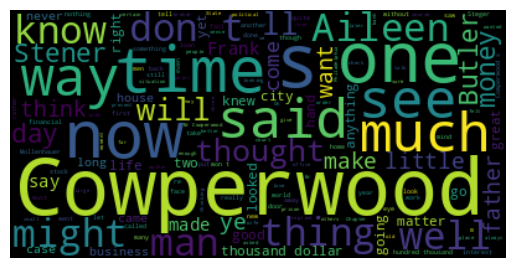

In [40]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

F = ' '.join(financier) # the whole book collapsed into one very long string
wordcloud = WordCloud().generate(F)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

## Question 3

Find lines of "The Fiancier" most similar to the query "New York Stock Exchange". You will get a higher score if you manage to re-write Fedor's functions in a vectorized manner. And you will get a higher score if you manage to split the book into paragraphs rather than into lines.

We have already combined all the lines of the novel into one very long string. Now we will split it by two line breaks:

In [41]:
financier_by_paragraph = F.split("\n \n")

print("Here is the beginning of 'The Financier' split into paragraphs:")
financier_by_paragraph[:20]

Here is the beginning of 'The Financier' split into paragraphs:


['\ufeff\n The Project Gutenberg EBook of The Financier, by Theodore Dreiser',
 ' This eBook is for the use of anyone anywhere at no cost and with\n almost no restrictions whatsoever.  You may copy it, give it away or\n re-use it under the terms of the Project Gutenberg License included\n with this eBook or online at www.gutenberg.org',
 ' \n Title: The Financier',
 ' Author: Theodore Dreiser',
 ' Release Date: February 25, 2006 [EBook #1840]\n Last Updated: December 1, 2019',
 ' Language: English',
 ' Character set encoding: UTF-8',
 ' *** START OF THIS PROJECT GUTENBERG EBOOK THE FINANCIER ***',
 ' ',
 ' \n Produced by Kirk Pearson and David Widger',
 ' ',
 ' \n The Financier',
 ' by Theodore Dreiser',
 ' \n Contents',
 '  Chapter I\n  Chapter II\n  Chapter III\n  Chapter IV\n  Chapter V\n  Chapter VI\n  Chapter VII\n  Chapter VIII\n  Chapter IX\n  Chapter X\n  Chapter XI\n  Chapter XII\n  Chapter XIII\n  Chapter XIV\n  Chapter XV\n  Chapter XVI\n  Chapter XVII\n  Chapter XVIII\n  Ch

We could probably do a bit of work with it by removing the metadata and other unnecessary things. But let's just get going.

The next step to vetorize it is by constructing the document-term matrix. Note that document vectors are just rows of the matrix product
$$
\mbox{DTM}\cdot \mbox{GloVe}^{T},
$$
where $\mbox{GloVe}$ is the matrix whose rows represent words and columns entries of word vectors.

The caveat is that columns of $\mbox{DTM}$ and columns of $\mbox{GloVe}$ should match, i.e., we can't just use the pretrained model as we downloaded it.

Let's get going! The first step is to construct the DTM

In [42]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer()
X = vec.fit_transform(financier_by_paragraph)
DTM = pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())
print("dim(DTM) =", print(DTM.shape))
print("A sample of words that appear in the novel:")
print(DTM.columns[200:220])

(2622, 10984)
dim(DTM) = None
A sample of words that appear in the novel:
Index(['addition', 'additional', 'additions', 'address', 'addressed',
       'addresses', 'addressing', 'adelaide', 'adequate', 'adequately',
       'adhere', 'adhered', 'adherent', 'adieu', 'adjoining', 'adjourned',
       'adjudged', 'adjudicated', 'adjust', 'adjusted'],
      dtype='object')


The next step is to filter out words that appear in the novel but for which we do not have pre-trained GloVe vectors. In other words, we only need to keep words that belong to $V_{novel}\cap V_{GloVe}$, where $V_{novel}$ is the vocabulary of the novel and $V_{GloVe}$ is the vocabulary of the GloVe model.

In [43]:
df_glove.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
the,-0.038194,-0.244870,0.72812,-0.399610,0.083172,0.043953,-0.391410,0.334400,-0.57545,0.087459,...,0.016215,-0.017099,-0.389840,0.87424,-0.72569,-0.51058,-0.520280,-0.14590,0.82780,0.270620
",",-0.107670,0.110530,0.59812,-0.543610,0.673960,0.106630,0.038867,0.354810,0.06351,-0.094189,...,0.349510,-0.722600,0.375490,0.44410,-0.99059,0.61214,-0.351110,-0.83155,0.45293,0.082577
.,-0.339790,0.209410,0.46348,-0.647920,-0.383770,0.038034,0.171270,0.159780,0.46619,-0.019169,...,-0.063351,-0.674120,-0.068895,0.53604,-0.87773,0.31802,-0.392420,-0.23394,0.47298,-0.028803
of,-0.152900,-0.242790,0.89837,0.169960,0.535160,0.487840,-0.588260,-0.179820,-1.35810,0.425410,...,0.187120,-0.018488,-0.267570,0.72700,-0.59363,-0.34839,-0.560940,-0.59100,1.00390,0.206640
to,-0.189700,0.050024,0.19084,-0.049184,-0.089737,0.210060,-0.549520,0.098377,-0.20135,0.342410,...,-0.131340,0.058617,-0.318690,-0.61419,-0.62393,-0.41548,-0.038175,-0.39804,0.47647,-0.159830


In [44]:
words_existing_in_text_and_glove = set(DTM.columns).intersection(set(df_glove.index))
print("Found ", len(words_existing_in_text_and_glove), "words in the novel for which we have word vectors")

Found  10610 words in the novel for which we have word vectors


Now we will subset the raw DTM computed from the novel and the raw GloVe embeddings downloaded from Stanford by taking only words that appear in both sets.

In [45]:
DTM_relevant = DTM[list(words_existing_in_text_and_glove)]
glove_relevant = df_glove.loc[list(words_existing_in_text_and_glove)]
print("dim(DTM =", DTM_relevant.shape)
print("Sample of DTM:")
print(DTM_relevant.iloc[:5, :5])
print("\ndim(GloVe) =", glove_relevant.shape)
print("Sample of GloVe:")
print(glove_relevant.iloc[:5, :5])
print("\nSanity check: the order of columns of DTM should be the same as the order of indices of GloVe")
print("The following should be 0:")
print(np.sum(DTM_relevant.columns != glove_relevant.index))

dim(DTM = (2622, 10610)
Sample of DTM:
   necessitated  author  cautiously  american  extracted
0             0       0           0         0          0
1             0       0           0         0          0
2             0       0           0         0          0
3             0       1           0         0          0
4             0       0           0         0          0

dim(GloVe) = (10610, 100)
Sample of GloVe:
                    0        1         2         3        4
necessitated -0.18696 -0.26551 -0.346690  0.318110 -0.31972
author       -0.41300  0.21800  0.039431 -0.053749  0.85308
cautiously   -0.56062  0.29265 -0.101620  0.551480 -0.14195
american      0.38666  0.64827  0.728070 -0.077056  0.15450
extracted    -0.16965  0.95783  0.019051  0.001597  0.43135

Sanity check: the order of columns of DTM should be the same as the order of indices of GloVe
The following should be 0:
0


Now we can compute document vectors - it is simply the product of the two matrices.

In [46]:
doc_vectors = np.dot(DTM_relevant, glove_relevant)
print("dim(Doc Vectors) =", doc_vectors.shape)
print("Sample of doc vectors:")
print(doc_vectors[:5, :5])

dim(Doc Vectors) = (2622, 100)
Sample of doc vectors:
[[ 2.16355205  1.90673996  1.69457012 -2.5500268   4.40642402]
 [-3.68537701  8.89949586 18.05343715 -8.12144096  4.27336805]
 [ 1.679676   -0.48157999  1.72432002 -1.09823     1.95059196]
 [ 0.73024002  1.11529002 -0.39414901 -0.45084579  1.22272997]
 [ 0.65829793 -1.58091308  2.17706203 -0.23848799  2.61171998]]


_Note about Python nuances_: we are using two libraries here - `numpy` for fast matrix operations and `pandas` for dataframes. The latter is more efficient for extracting numeric data from Python dictionaries and is more convenient for our current task because it automatically labels rows and columns of matrices. The difference in working with the two types of matrix data is in subsetting matrices. With `pandas` dataframes, we use methods `.loc` and `.iloc` but with `numpy` matrices we just use double indexing. Please pay attention to the difference between these data types. If you get an error message, it means that you have likey tried an incorrect method of extracting elements from or subsetting a matrix.

Here are types of the matrices we are currently working with:

In [47]:
print("Type of DTM:", type(DTM_relevant))
print("Type of GloVe:", type(glove_relevant))
print("Type of doce vectors:", type(doc_vectors))
print("Type of the document list:", type(financier_by_paragraph))
print("Type of the word list:", type(words_existing_in_text_and_glove))

Type of DTM: <class 'pandas.core.frame.DataFrame'>
Type of GloVe: <class 'pandas.core.frame.DataFrame'>
Type of doce vectors: <class 'numpy.ndarray'>
Type of the document list: <class 'list'>
Type of the word list: <class 'set'>


Now we are ready to perform our query search. To do it, we will modify the function that extracts most similar words from a word embedding matrix. There will be two changes:

1. Computing norms of document vectors, we will replace 0 with 0.001 to avoid division by 0. Empty documents will not appear in the search anyway since the computed cosine similarity with them will be 0 (strictly speaking, cosine similarity with a zero vector is just undefined).

2. The function returns a list of texts rather than a dataframe or a matrix.

Note that to do it, Fedor converted a Python list of strings that the novel is stored in into a `numpy` array of strings. This is because Fedor doesn't know how to subset of slice Python lists. On the other hand, `numpy` arrays are easy to subset.

In [48]:
query_vector = text_to_vector("new york stock exchange")

def top_most_similar_docs(x, n = 10, doc_matrix = doc_vectors, docs = financier_by_paragraph):
    # Returns the list of top n documents with highest cosine similarity to vector x
    dot_products = np.dot(doc_matrix, x)
    word_vector_norms = np.sqrt(np.square(doc_matrix).sum(1))
    word_vector_norms[word_vector_norms == 0] = 0.001 # to avoid division by 0
    x_norm = np.linalg.norm(x)
    all_cosine_similarities = dot_products / (word_vector_norms * x_norm)
    return np.array(docs)[np.argsort(-all_cosine_similarities)][:n]

top_results = top_most_similar_docs(query_vector, 5)

for i in range(len(top_results)):
    print(top_results[i], "\n\n")

 “The American Trust Company of New York has suspended payment.” 


 “The Eastern and Western Fire Insurance Company of New York announces
 that it cannot meet its obligations.” 


 What was more, the money system of the United States was only then
 beginning slowly to emerge from something approximating chaos to
 something more nearly approaching order. The United States Bank, of
 which Nicholas Biddle was the progenitor, had gone completely in 1841,
 and the United States Treasury with its subtreasury system had come in
 1846; but still there were many, many wildcat banks, sufficient in
 number to make the average exchange-counter broker a walking
 encyclopedia of solvent and insolvent institutions. Still, things were
 slowly improving, for the telegraph had facilitated stock-market
 quotations, not only between New York, Boston, and Philadelphia, but
 between a local broker’s office in Philadelphia and his stock exchange.
 In other words, the short private wire had been introduced.


## Question 4

Given a corpus of documents and a list $V$ of terms (vocabulary) that appear in the documents,
recall that the GloVe model is a map
$$
G:V\to\mathbb{R}^d,
$$
i.e., it assigns vectors to words from the vocabulary. Here, $d$ is the model's dimension.

The GloVe model is trained by minimizing a certain loss function. Prove that if $d\ge 2$, then the minimum is not unique. Moreover, there are infinitely many choices of vectors that minimize the loss function.

The GloVe loss is
$$
L(w,\tilde{w},b,\tilde{b})=
\sum_{i,k=1}^{|V|} f(X_{ik})
\left(w_i^{T}\tilde{w}_k+b_i+\tilde{b}_k-\log X_{ik}\right)^2,
$$
where $X_{ik}$ is the co-occurrence of terms $i$ and $k$.
Here, $w_i$ are so-called word vectors and $\tilde{w}_k$ context vectors.
The resulting model is
$$
v_i=w_i+\tilde{w}_i
$$
Note that if $M$ is any $d\times d$ orthogonal matrix, then
$$
w_i^{T}\tilde{w}_k=
w_i^{T}M^{T}M\tilde{w}_k=
\left(Mw_i\right)^{T}\left(M\tilde{w}_k\right),
$$
i.e., if we simultaneously multiply all word vectors $w_i$ and all context vectors $\tilde{w}_k$ by $M$, the loss won't change. It means that if some choice of word and context vectors $(w,\tilde{w})$ minimizes the loss function, then so does $(Mw,M\tilde{w})$. Since there are infinitely many orthogonal matrices, the GloVe loss has infinitely many points of minimum.

__Note__: Because of this, individual entries of word vectors are not inrepretable, even though the original motivation to construct word vectors was to give some meaning to their entries.

## Question 5

Here, we used pre-trained GloVe to find lines of "The Financier" most similar to the query. Wouldn't it be better to train our own version of GloVe just on "The Financier"?

Explain.

The power of pre-trained word vectors is that they are trained on a very large corpus and hence are able to capture rich semantic relationships. For insance, there may be words that are similar in meaning, but they don't happen to appear in the same context in "The Financier" and hence if we train our GloVe model just on "The Financier", our model won't reconize their similarity.

An ideal solution will be to train word embeddings on a large corpus that contains a lot of documents similar to the document that we are working with. For example, it may be more appropriate to train word vectors on a corpus of American literature of the first half of XX century. Such word embeddings could be better suitable for working with "The Financier" than word embeddings trained on Wikipedia that we actually used.

## Question 6

Fedor is going to apply clustering analysis to the lines of "The Financier" by converting each line to a vector using the equation
$$
\sum_{w\in \mbox{line}} v(w)
$$
and then running the $k$-means clustering on it. What is wrong with this approach?

This is probably the easiest question - the problem with this approach is that $k$-means clustering is based on Euclidean distance while similarity between documents is the cosine similarity. The former is very much dependent on the norm of a vector and the latter just on direction.

Applying the $k$-means clustering to the document vectors directly will probably group together short documents (since their vectors will have a smaller norm) rather than documents with similar meaning.

To solve this problem, we just need to normalize all document vectors before applying $k$-means clustering.

## Question 7

Suppose that we want to evaluate the accuracy of our search algorithm. What kind of data will we need and how expensive will it be to create such a dataset?

In the perfect world, to evalate the accuracy of our search algorithm, we need a labelled dataset containing a number of queries and a list of top 5 or top 10 most relevant paragraphs to that query. Then accuracy of our search algorithm can be measured as the fraction of paragraphs overlapping with the labelled dataset.

However, there are are some important issues here. The first issue is how we create such a labelled dataset. It would require an expert who manually finds most relevant paragraphs to a lot of queries. It cannot be just someone who read the book once - it should be someone who is really familiar with the content of every particular paragraph. The second issue is how we generate a set of queries for the test data. Do we get it from some librarian who helps students of English literature to write essays on "The Financier"? Even if we generate such a test set somehow and measure the accuracy of our search algorithm, the third issue is benchmarking. What is good and what is bad accuracy? To be able to benchmark our search algorithm, we should really hire several experts who will manually find relevant paragraphs to a lot of queries, form an "absolute" test set by merging the experts' work and then compute the average accuracy of these human experts against the "absolute" test set. This will be a really good benchmark.

To create such a dataset, we will probably need to hire a few professors of English literature as experts. Let's say that we will hire 5 professors for a week as consultants and pay them in proportion to their annual salary. According to [this article](https://learn.org/articles/English_Literature_Professor_Your_Salary_and_Career_Questions_Answered.html), the average annual salary of an Enlgish literature professor is 81340 USD. It means that the rough estimate for what we need to pay our experts for creating the dataset is
$$
\frac{81340\times 5}{52},
$$
i.e., 8000 USD (rounded to a thousand).